### PS Model Diagnostics

In [60]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [ ]:
# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

# for some reason .ipynb Code does not let me use relative paths...
FEATURE_DIR = os.path.join("/Users/chanyoungwoo/Thesis/","Data_Pipeline", "splits_ver10")
NUISANCE_DIR = os.path.join("/Users/chanyoungwoo/Thesis/","ATE_CATE", "PS_validation")
TRAIN_FP = os.path.join(FEATURE_DIR, "cand_kipa_train_ver10.parquet")
PS_FP = os.path.join(NUISANCE_DIR, "ps_cand_kipa_train.parquet")
META_FP = os.path.join("/Users/chanyoungwoo/Thesis/","Data_Pipeline", "meta_data", "meta_data_ver10.csv")

df      = pd.read_parquet(TRAIN_FP)
ps_df   = pd.read_parquet(PS_FP)
meta    = pd.read_csv(META_FP, dtype=str)

# merge PS into data
df = df.merge(ps_df, on="PX_ID", how="left")
if df["ps"].isna().any():
    raise ValueError("Missing PS values after merge!")

# compute IPTW weights
df["iptw"] = np.where(df["T_365"] == 1,
                      1.0 / df["ps"],
                      1.0 / (1.0 - df["ps"]))

#### 1. PS distributions

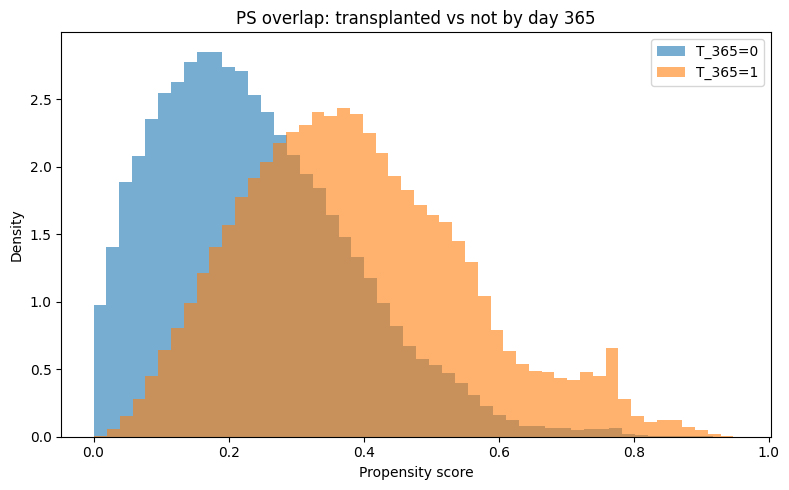

In [59]:
plt.figure(figsize=(8,5))
for label, grp in df.groupby("T_365"):
    plt.hist(grp["ps"], bins=50, density=True,
             alpha=0.6,
             label=f"T_365={label}")
plt.xlabel("Propensity score")
plt.ylabel("Density")
plt.title("PS overlap: transplanted vs not by day 365")
plt.legend()
plt.tight_layout()
plt.savefig("ps_overlap.png")
plt.show()

- Overlap looks pretty good
- trim the extreme tails

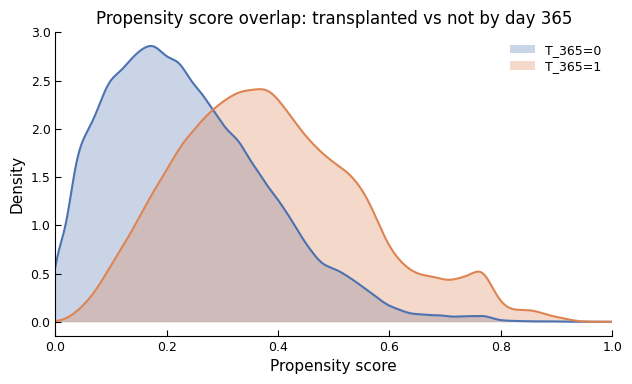

In [ ]:
colors = {0: "#4C72B0", 1: "#DD8452"}  # blue and orange

plt.figure(figsize=(6.5, 4))  # slightly more compact

for label, grp in df.groupby("T_365"):
    data = grp["ps"].dropna().values
    if len(data) < 2:
        continue  # skip if insufficient for KDE

    # Compute KDE with automatic bandwidth (Silverman)
    kde = gaussian_kde(data)
    x_eval = np.linspace(0, 1, 1000)
    y_eval = kde(x_eval)

    # Plot smooth filled curve with a thin edge for definition
    plt.fill_between(
        x_eval,
        y_eval,
        alpha=0.3,
        label=f"T_365={label}",
        color=colors.get(label, None),
        linewidth=0
    )
    plt.plot(
        x_eval,
        y_eval,
        linewidth=1.5,
        color=colors.get(label, None)
    )

plt.xlabel("Propensity score", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Propensity score overlap: transplanted vs not by day 365", fontsize=12)
plt.xlim(0, 1)
plt.tight_layout()

plt.gca().tick_params(axis="both", which="major", labelsize=9, length=4, direction="in")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(frameon=False, fontsize=9, labelspacing=0.3)

plt.savefig("ps_overlap.pdf")          
plt.savefig("ps_overlap.png", dpi=600) 
plt.show()

#### 2. compute SMDs before & after weighting

In [ ]:
cont_feats = meta.query("group=='a_continuous_numeric'")["Variable"].tolist()
# drop any outcome/time‐related cols
drop = {"PX_ID","WL_TIME","WL_EVENT","TX_TIME","TX_EVENT",
         "GRAFT_TIME","GRAFT_EVENT","Y","Delta","T","T_365"}
cont_feats = [c for c in cont_feats
            if c in df.columns and c not in drop]

def smd(x_t, x_c, w_t=None, w_c=None):
    # weighted or unweighted
    if w_t is None:
        m_t = x_t.mean()
        v_t = x_t.var(ddof=0)
    else:
        m_t = np.average(x_t, weights=w_t)
        # weighted var
        v_t = np.average((x_t - m_t)**2, weights=w_t)
    if w_c is None:
        m_c = x_c.mean()
        v_c = x_c.var(ddof=0)
    else:
        m_c = np.average(x_c, weights=w_c)
        v_c = np.average((x_c - m_c)**2, weights=w_c)
    pooled_sd = np.sqrt((v_t + v_c) / 2)
    return (m_t - m_c) / pooled_sd if pooled_sd > 0 else 0.0

In [ ]:
smds = []
for feat in cont_feats:
    x = df[feat].astype(float)
    t_mask = df["T_365"] == 1
    c_mask = ~t_mask

    # unweighted
    s_un = smd(x[t_mask], x[c_mask])
    # weighted ->use IPTW
    s_w = smd(x[t_mask], x[c_mask],
              w_t=df.loc[t_mask, "iptw"],
              w_c=df.loc[c_mask, "iptw"])
    smds.append((feat, s_un, s_w))
    
smd_df = pd.DataFrame(smds, columns=["feature","smd_un","smd_w"])
smd_df["abs_un"] = smd_df["smd_un"].abs()
smd_df["abs_w"]  = smd_df["smd_w"].abs()
smd_df = smd_df.sort_values("abs_un", ascending=False)

# print top 10 imbalances before weighting
print("\nTop 10 pre‐weighting imbalances:")
print(smd_df.head(10)[["feature","smd_un","smd_w"]].to_string(index=False))



Top 10 pre‐weighting imbalances:
               feature    smd_un     smd_w
CAN_MAX_PCT_SCLER_LT10  0.231301  0.013214
              MAX_CPRA -0.220669 -0.038468
   CAN_MIN_FINAL_CREAT  0.202544  0.003130
    CAN_MIN_PEAK_CREAT  0.188552  0.004403
               CAN_BMI -0.168389 -0.049929
    CAN_AGE_AT_LISTING -0.116615 -0.017352
       CAN_TOT_ALBUMIN  0.027426 -0.002421
       CAN_TOT_ALBUMIN  0.027426 -0.002421


#### 3. plot SMDs

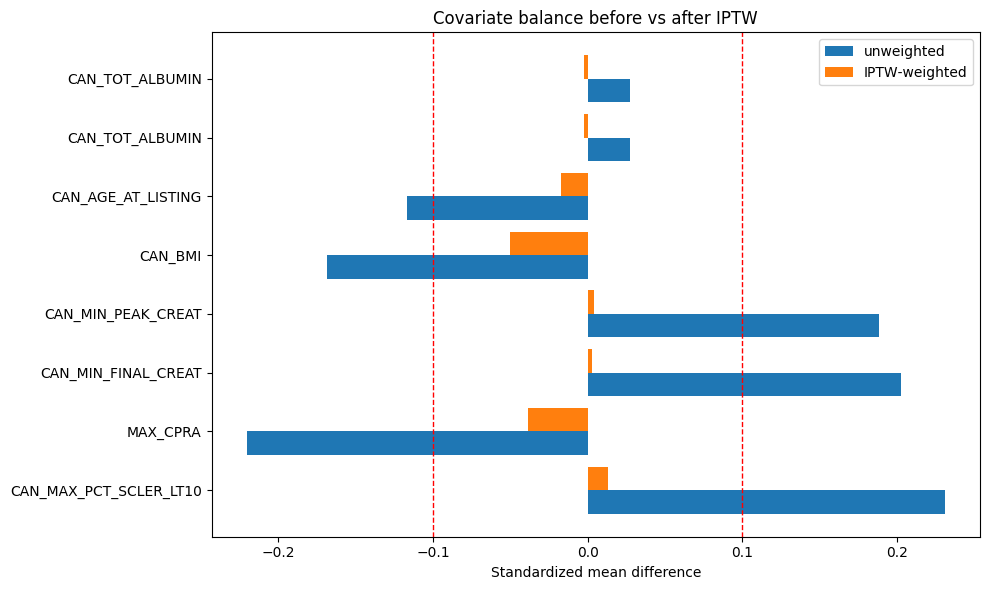

In [53]:
plt.figure(figsize=(10,6))
y = np.arange(len(smd_df))
plt.barh(y - 0.2, smd_df["smd_un"],  height=0.4, label="unweighted")
plt.barh(y + 0.2, smd_df["smd_w"],   height=0.4, label="IPTW‐weighted")
plt.yticks(y, smd_df["feature"])
plt.axvline( 0.1, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.1, color="red", linestyle="--", linewidth=1)
plt.xlabel("Standardized mean difference")
plt.title("Covariate balance before vs after IPTW")
plt.legend()
plt.tight_layout()
plt.savefig("ps_balance.png")
plt.show()


#### Propensity Score Overlap Diagnostics

We want to check what fraction of our sample lies in the tails (ps < 0.05 or ps > 0.95), review key quantiles, and visualize the distribution to decide on trimming or winsorization. ->Warning: R callback write-console:  Estimated treatment propensities take values very close to 0 or 1. The estimated propensities are between 0.01 and 0.911, meaning some estimates may not be well identified.


Fraction ps < 0.05: 4.923%
Fraction ps > 0.95: 0.000%

Propensity score quantiles:
        ps_hat
0.01  0.011435
0.05  0.050513
0.50  0.258007
0.95  0.578023
0.99  0.760040


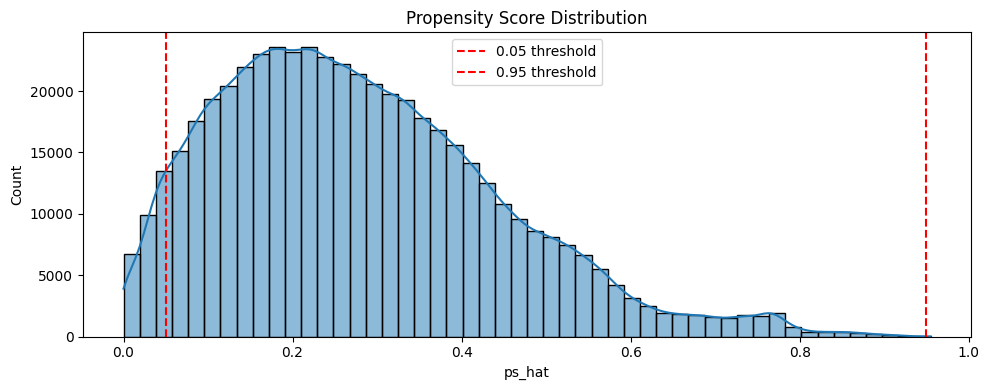


Counts by bin:
(-0.001, 0.05]     24811
(0.05, 0.95]      479119
(0.95, 1.0]            1
Name: count, dtype: int64


In [55]:
ps = ps_df['ps']

frac_low  = (ps < 0.05).mean()
frac_high = (ps > 0.95).mean()
print(f"Fraction ps < 0.05: {frac_low:.3%}")
print(f"Fraction ps > 0.95: {frac_high:.3%}")

print("\nPropensity score quantiles:")
print(ps.quantile([0.01, 0.05, 0.50, 0.95, 0.99]).to_frame(name='ps_hat'))

# Histogram + KDE with trim lines
plt.figure(figsize=(10, 4))
sns.histplot(ps, bins=50, kde=True)
plt.axvline(0.05, color='red', linestyle='--', label='0.05 threshold')
plt.axvline(0.95, color='red', linestyle='--', label='0.95 threshold')
plt.title("Propensity Score Distribution")
plt.xlabel("ps_hat")
plt.legend()
plt.tight_layout()
plt.show()

# tabulate exact counts by bin
bins = [0, 0.05, 0.95, 1.0]
counts = ps.value_counts(bins=bins, sort=False)
print("\nCounts by bin:")
print(counts)

Key Findings: 

- Non-negligible left tail (PS < 0.05): about 5 % of cohort have PS below 0.05, meaning they’re extremely unlikely to get a transplant by day 365. These low-PS individuals will receive very large IPTW (≈ 1/PS > 20), inflating variance.
- Trim extremes 

Action: 
- Trim observations with ps < 0.5 && ps >0.95

Fraction ps < 0.05: 4.923%
Fraction ps > 0.95: 0.000%

Propensity score quantiles:
        ps_hat
0.01  0.011435
0.05  0.050513
0.50  0.258007
0.95  0.578023
0.99  0.760040

Counts by bin:
ps
(-0.001, 0.05]     24811
(0.05, 0.95]      479119
(0.95, 1.0]            1
Name: count, dtype: int64


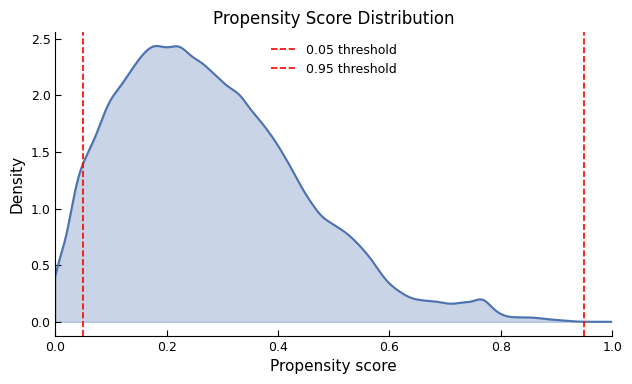

In [ ]:
ps = ps_df["ps"].dropna()

# Summary statistics
frac_low = (ps < 0.05).mean()
frac_high = (ps > 0.95).mean()
print(f"Fraction ps < 0.05: {frac_low:.3%}")
print(f"Fraction ps > 0.95: {frac_high:.3%}\n")

print("Propensity score quantiles:")
print(ps.quantile([0.01, 0.05, 0.50, 0.95, 0.99]).to_frame(name="ps_hat"))

# Counts in bins (exact)
bins = [0.0, 0.05, 0.95, 1.0]
counts = pd.cut(ps, bins=bins, right=True, include_lowest=True)
print("\nCounts by bin:")
print(counts.value_counts().sort_index())

# Plotting
plt.figure(figsize=(6.5, 4))

# KDE
data = ps.values
if len(data) >= 2:
    kde = gaussian_kde(data)
    x_eval = np.linspace(0, 1, 1000)
    y_eval = kde(x_eval)
    plt.fill_between(x_eval, y_eval, alpha=0.3, color="#4C72B0")
    plt.plot(x_eval, y_eval, linewidth=1.5, color="#4C72B0")


# Threshold lines
for thresh, label in [(0.05, "0.05 threshold"), (0.95, "0.95 threshold")]:
    plt.axvline(
        thresh,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=label
    )

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), frameon=False, fontsize=9)


plt.xlabel("Propensity score", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Propensity Score Distribution", fontsize=12)
plt.xlim(0, 1)
plt.tight_layout()
plt.gca().tick_params(axis="both", which="major", labelsize=9, length=4, direction="in")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.savefig("ps_distribution.pdf")       
plt.savefig("ps_distribution.png", dpi=600) 
plt.show()